
# Sliding-window one-swap similarity under drifting Gaussian mixtures

This notebook simulates a time-indexed distribution. At every time beat we draw one 2D sample from a mixture of about ten Gaussians. The mixture weights, centers, and variances drift slowly. Some component weights are forced to exactly zero for intervals and then reactivated; when a component reactivates, its center jumps to a new location, creating an effective blob “teleport.”

We then compare consecutive sliding windows:

```python
X_t = points[t : t + window]
Y_t = points[t + 1 : t + window + 1]
```

These windows differ by one removed point and one added point, so the indexed one-swap routine applies directly.


In [1]:

from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Keep pointcloud_similarity.py in the same folder as this notebook.
module_dir = Path.cwd()
if str(module_dir) not in sys.path:
    sys.path.insert(0, str(module_dir))


import pointcloud_similarity as pcs
print("Using pointcloud_similarity from:", pcs.__file__)
print("pointcloud_similarity version:", getattr(pcs, "__version__", "unknown"))
_required = [
    "emst",
    "pointcloud_similarity_index_sets",
    "pointcloud_similarity_from_common_indices",
    "similarity_integrals_from_msts",
]
_missing = [name for name in _required if not hasattr(pcs, name)]
assert not _missing, f"pointcloud_similarity.py is missing required public names: {_missing}"

from pointcloud_similarity import pointcloud_similarity_from_common_indices


Using pointcloud_similarity from: /home/asmi28/python_code/miniSAGA/pointcloud_similarity.py
pointcloud_similarity version: 0.5.1


In [2]:

CONFIG = {
    "seed": 16,
    "T": 600,
    "K": 10,
    "window": 35,
    "mst_method": "auto",

    # Smooth drift parameters.
    "center_scale": 6.0,
    "drift_scale": 0.025,
    "mean_reversion": 0.008,
    "sigma_base": 0.25,
    "sigma_amplitude": 0.40,
    "weight_temperature": 0.80,

    # Teleport parameters applied at component reactivation times.
    "teleport_min_radius": 10.0,
    "teleport_max_radius": 15.0,
    "reactivation_boost": 5.5,
    "boost_duration": 20,

    # Intervals are [start, end). The corresponding mixture coefficient is
    # exactly zero throughout the interval, then the component reappears.
    "zero_intervals": {
        1: [(75, 125), (340, 385)],
        4: [(155, 215)],
        7: [(255, 315)],
        8: [(395, 450)],
    },
}


In [3]:

def random_center(rng, r_min, r_max):
    theta = rng.uniform(0, 2 * np.pi)
    radius = rng.uniform(r_min, r_max)
    return np.array([radius * np.cos(theta), radius * np.sin(theta)])


def softmax_masked(logits, active, temperature):
    z = logits / temperature
    z = z.copy()
    z[~active] = -np.inf
    if not np.any(active):
        raise ValueError("At least one component must be active at every time.")
    m = np.max(z[active])
    e = np.zeros_like(z)
    e[active] = np.exp(z[active] - m)
    return e / e.sum()


def simulate_drifting_mixture(config):
    rng = np.random.default_rng(config["seed"])
    T = config["T"]
    K = config["K"]

    active = np.ones((T, K), dtype=bool)
    reactivations = []
    for k, intervals in config["zero_intervals"].items():
        for start, end in intervals:
            active[start:end, k] = False
            if end < T:
                reactivations.append((end, k))

    reactivation_by_time = {}
    for t, k in reactivations:
        reactivation_by_time.setdefault(t, []).append(k)

    home = np.vstack([
        random_center(rng, 3.5, config["center_scale"])
        for _ in range(K)
    ])
    current_centers = home.copy()
    velocities = rng.normal(scale=config["drift_scale"], size=(K, 2))

    centers = np.empty((T, K, 2))
    sigmas = np.empty((T, K))
    weights = np.empty((T, K))

    phase = rng.uniform(0, 2 * np.pi, K)
    phase2 = rng.uniform(0, 2 * np.pi, K)
    freq = rng.uniform(0.010, 0.030, K)
    freq2 = rng.uniform(0.004, 0.012, K)

    for t in range(T):
        if t > 0:
            velocities = 0.96 * velocities + rng.normal(
                scale=config["drift_scale"] * 0.25,
                size=(K, 2),
            )
            current_centers = (
                current_centers
                + velocities
                + config["mean_reversion"] * (home - current_centers)
            )

        # Teleport a component exactly when it leaves a zero-weight interval.
        for k in reactivation_by_time.get(t, []):
            current_centers[k] = random_center(
                rng,
                config["teleport_min_radius"],
                config["teleport_max_radius"],
            )
            velocities[k] = rng.normal(scale=config["drift_scale"], size=2)

        centers[t] = current_centers

        logits = (
            1.1 * np.sin(freq * t + phase)
            + 0.7 * np.cos(freq2 * t + phase2)
        )
        for t0, k in reactivations:
            if t0 <= t < min(T, t0 + config["boost_duration"]):
                logits[k] += config["reactivation_boost"]

        weights[t] = softmax_masked(logits, active[t], config["weight_temperature"])
        sigmas[t] = np.clip(
            config["sigma_base"] * (1 + config["sigma_amplitude"] * np.sin(0.025 * t + phase2)),
            0.08,
            None,
        )

    components = np.empty(T, dtype=int)
    points = np.empty((T, 2))
    for t in range(T):
        components[t] = rng.choice(K, p=weights[t])
        points[t] = rng.normal(centers[t, components[t]], sigmas[t, components[t]])

    return points, components, weights, centers, sigmas, active, reactivations


In [4]:

points, components, weights, centers, sigmas, active, reactivations = simulate_drifting_mixture(CONFIG)

print(f"points shape: {points.shape}")
print("reactivations (time, component):", reactivations)


points shape: (600, 2)
reactivations (time, component): [(125, 1), (385, 1), (215, 4), (315, 7), (450, 8)]


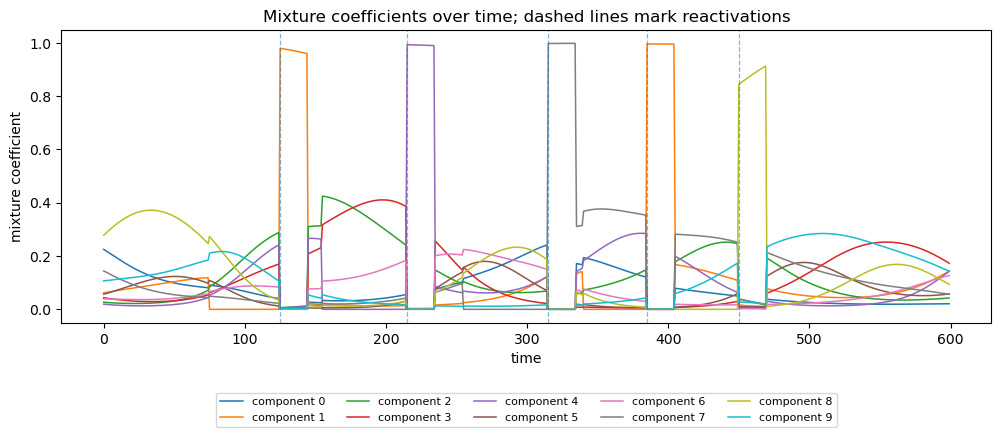

In [5]:

fig, ax = plt.subplots(figsize=(12, 3.8))
for k in range(CONFIG["K"]):
    ax.plot(weights[:, k], linewidth=1.1, label=f"component {k}")
for t, k in reactivations:
    ax.axvline(t, linestyle="--", linewidth=0.9, alpha=0.55)
ax.set_title("Mixture coefficients over time; dashed lines mark reactivations")
ax.set_xlabel("time")
ax.set_ylabel("mixture coefficient")
ax.legend(ncol=5, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.22))
plt.show()


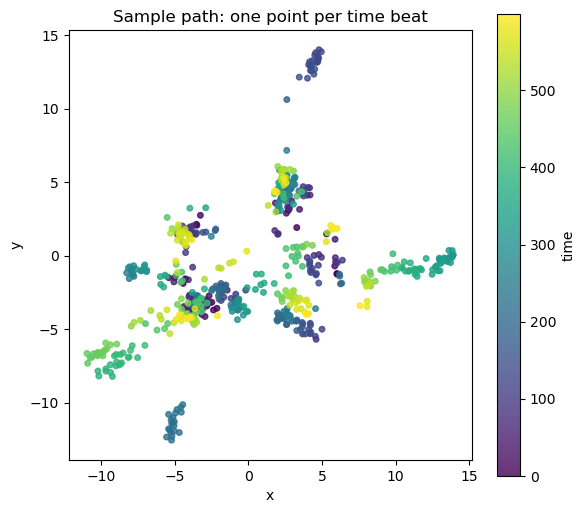

In [6]:

fig, ax = plt.subplots(figsize=(6.5, 6.0))
scatter = ax.scatter(points[:, 0], points[:, 1], c=np.arange(CONFIG["T"]), s=16, alpha=0.8)
ax.set_title("Sample path: one point per time beat")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal", adjustable="box")
plt.colorbar(scatter, ax=ax, label="time")
plt.show()


In [7]:
%%time
def compute_sliding_scores(points, components, weights, config, reactivations):
    T = config["T"]
    W = config["window"]
    records = []

    for start in range(T - W):
        # X = [start, ..., start+W-1]
        # Y = [start+1, ..., start+W]
        common_indices = np.arange(start + 1, start + W)
        x_index = start
        y_index = start + W

        result = pointcloud_similarity_from_common_indices(
            points,
            common_indices,
            x_index=x_index,
            y_index=y_index,
            mst_method=config.get("mst_method", "auto"),
        )

        added_component = int(components[y_index])
        reactivation_sample = any(
            (added_component == k) and (t0 <= y_index < t0 + config["boost_duration"])
            for t0, k in reactivations
        )
        near_reactivation = any(
            t0 <= y_index < t0 + config["boost_duration"]
            for t0, _ in reactivations
        )

        records.append({
            "window_start": start,
            "t_added": y_index,
            "s": result.s,
            "R": result.R,
            "conn_X": result.mst_X.max_edge,
            "conn_Y": result.mst_Y.max_edge,
            "conn_union": result.mst_union.max_edge,
            "removed_index": x_index,
            "added_index": y_index,
            "removed_component": int(components[x_index]),
            "added_component": added_component,
            "added_component_weight": weights[y_index, added_component],
            "reactivation_sample": reactivation_sample,
            "near_reactivation": near_reactivation,
        })

    return pd.DataFrame(records)


scores = compute_sliding_scores(points, components, weights, CONFIG, reactivations)
scores.describe()[["s", "R", "conn_X", "conn_Y", "conn_union"]]


CPU times: user 256 ms, sys: 11.8 ms, total: 268 ms
Wall time: 268 ms


,s,R,conn_X,conn_Y,conn_union
count,565.000000,565.000000,565.000000,565.000000,565.000000
mean,0.983037,6.803149,6.752970,6.751045,6.731053
std,0.030682,1.998609,1.968801,1.970493,1.957369
min,0.737365,4.374196,4.374196,4.374196,4.374196
25%,0.983423,5.252436,5.252436,5.232556,5.232556
50%,0.991971,6.026052,5.875721,5.875721,5.872148
75%,0.996405,8.157063,8.091810,8.091810,8.091810
max,1.004145,12.721238,12.721238,12.721238,12.721238


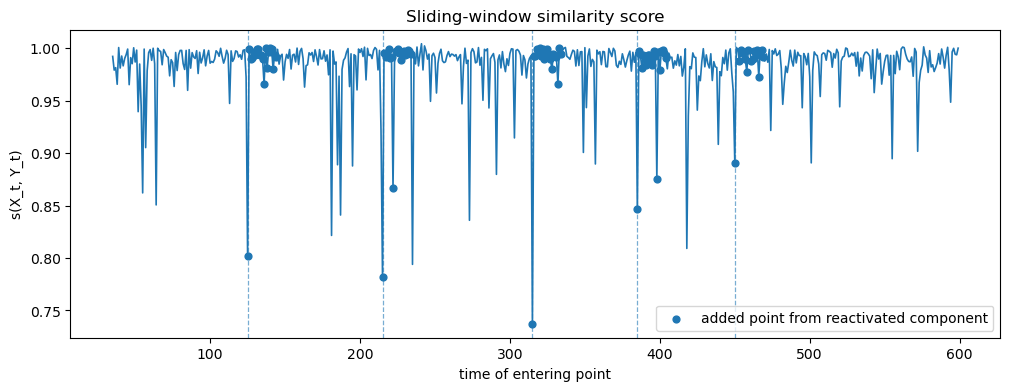

In [8]:

fig, ax = plt.subplots(figsize=(12, 4.0))
ax.plot(scores["t_added"], scores["s"], linewidth=1.2)
for t, k in reactivations:
    ax.axvline(t, linestyle="--", linewidth=0.9, alpha=0.6)
ax.scatter(
    scores.loc[scores["reactivation_sample"], "t_added"],
    scores.loc[scores["reactivation_sample"], "s"],
    s=24,
    label="added point from reactivated component",
)
ax.set_title("Sliding-window similarity score")
ax.set_xlabel("time of entering point")
ax.set_ylabel("s(X_t, Y_t)")
ax.legend(loc="best")
plt.show()


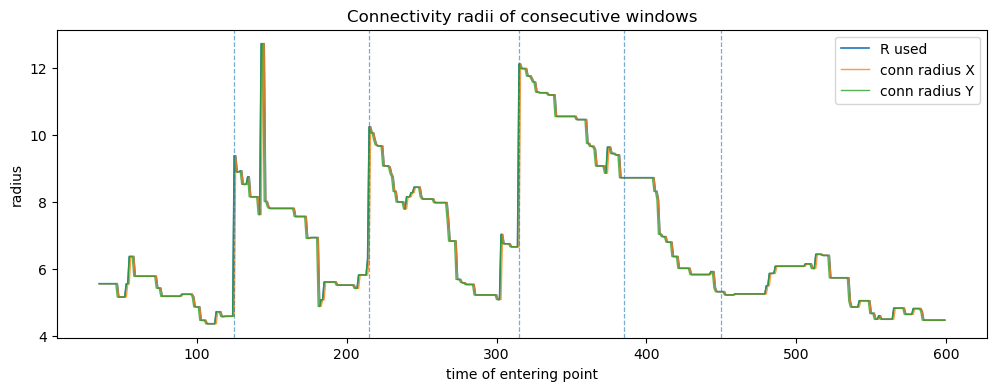

In [9]:

fig, ax = plt.subplots(figsize=(12, 4.0))
ax.plot(scores["t_added"], scores["R"], linewidth=1.2, label="R used")
ax.plot(scores["t_added"], scores["conn_X"], linewidth=1.0, alpha=0.8, label="conn radius X")
ax.plot(scores["t_added"], scores["conn_Y"], linewidth=1.0, alpha=0.8, label="conn radius Y")
for t, k in reactivations:
    ax.axvline(t, linestyle="--", linewidth=0.9, alpha=0.6)
ax.set_title("Connectivity radii of consecutive windows")
ax.set_xlabel("time of entering point")
ax.set_ylabel("radius")
ax.legend(loc="best")
plt.show()


In [10]:

# The lowest scores are the most visually obvious changes under this default simulation.
cols = [
    "t_added", "s", "R", "conn_X", "conn_Y",
    "removed_component", "added_component",
    "added_component_weight", "reactivation_sample", "near_reactivation",
]
scores.nsmallest(12, "s")[cols]


,t_added,s,R,conn_X,conn_Y,removed_component,added_component,added_component_weight,reactivation_sample,near_reactivation
280,315,0.737365,12.115129,6.666999,12.115129,6,7,0.997186,True,True
180,215,0.781804,10.241336,6.301856,10.241336,2,4,0.992651,True,True
200,235,0.793923,8.003492,8.003492,8.003492,7,0,0.075904,False,False
90,125,0.801637,9.376936,4.595705,9.376936,9,1,0.978784,True,True
383,418,0.809139,6.377084,6.377084,6.377084,9,6,0.017310,False,False
146,181,0.821517,6.941980,6.941980,4.891060,1,6,0.123759,False,False
238,273,0.835938,6.837707,6.837707,5.695668,4,6,0.206673,False,False
152,187,0.840948,5.617123,5.617123,5.617123,2,1,0.013078,False,False
350,385,0.846697,8.727002,8.727002,8.727002,7,1,0.995220,True,True
29,64,0.850583,5.789934,5.789934,5.789934,6,3,0.041729,False,False


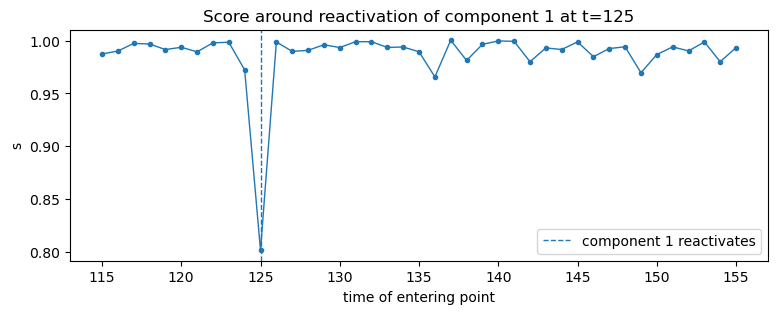

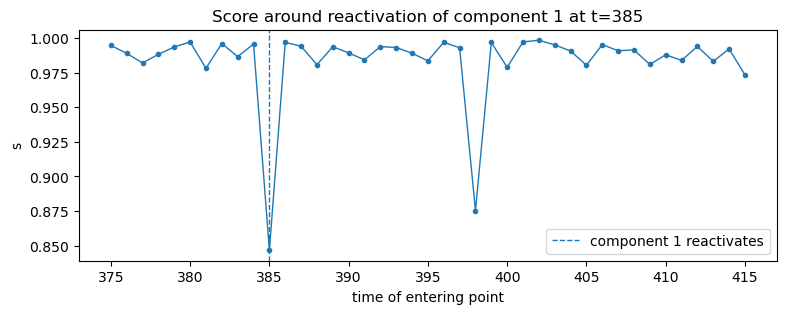

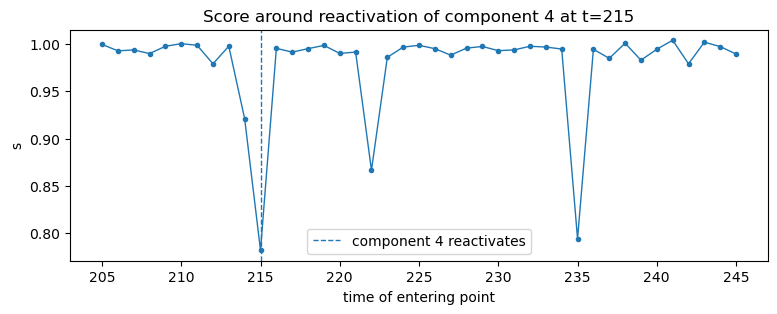

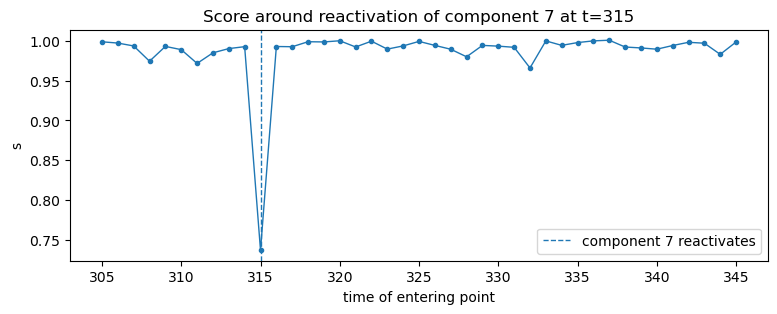

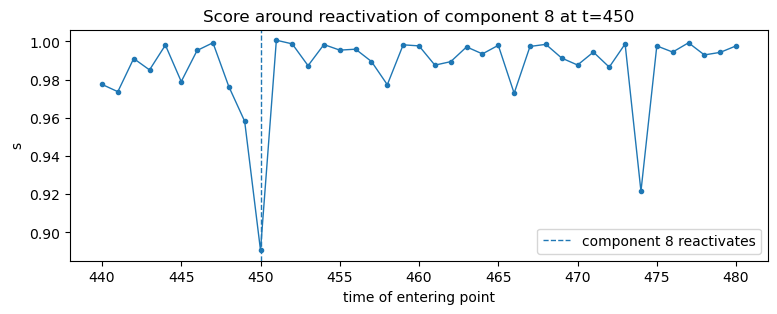

In [11]:

# Zoom around every reactivation. The entering time t_added is the natural x-axis.
for t0, k in reactivations:
    lo = max(scores["t_added"].min(), t0 - 10)
    hi = min(scores["t_added"].max(), t0 + CONFIG["boost_duration"] + 10)
    chunk = scores[(scores["t_added"] >= lo) & (scores["t_added"] <= hi)]

    fig, ax = plt.subplots(figsize=(9, 3.0))
    ax.plot(chunk["t_added"], chunk["s"], marker="o", linewidth=1.0, markersize=3)
    ax.axvline(t0, linestyle="--", linewidth=1.0, label=f"component {k} reactivates")
    ax.set_title(f"Score around reactivation of component {k} at t={t0}")
    ax.set_xlabel("time of entering point")
    ax.set_ylabel("s")
    ax.legend(loc="best")
    plt.show()



Tuning suggestions:

- Increase `teleport_min_radius` / `teleport_max_radius` to make reactivated blobs farther away.
- Increase `reactivation_boost` to make the reactivated component more likely to be sampled immediately.
- Decrease `window` to make each entering point have more influence.
- Increase `sigma_base` or `sigma_amplitude` to blur blobs and soften the MST changes.
- Edit `zero_intervals` to add or remove forced disappear/reappear events.
